In [20]:
import pandas as pd
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

In [22]:
# Step 2: Load and preprocess
df = pd.read_csv("/content/sample_data/Sentiment_Data.csv", encoding="ISO-8859-1").dropna(subset=['Tweet'])


In [23]:
def clean_tweet(tweet):
    tweet = re.sub(r"@\w+", "", tweet)
    tweet = re.sub(r"http\S+|www\S+", "", tweet)
    tweet = re.sub(r"[^A-Za-z\s]", "", tweet)
    tweet = tweet.lower().strip()
    return tweet

In [24]:
df['clean_tweet'] = df['Tweet'].apply(clean_tweet)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Sentiment'])

TF-DF


In [25]:
# Step 3: TF-IDF
df_sampled = df.sample(n=20000, random_state=42)
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
X = tfidf.fit_transform(df_sampled['clean_tweet']).toarray()
y = to_categorical(df_sampled['label'])

In [26]:
# Step 4: Train/test split and reshape for RNN
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

**Implement unidirectional RNN Model**

In [28]:
# Step 5: RNN model
model = Sequential([
    SimpleRNN(128, activation='relu', return_sequences=True, input_shape=(1, X_train.shape[2])),
    Dropout(0.3),
    SimpleRNN(64, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(y.shape[1], activation='softmax')
])

In [29]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))


Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.5117 - loss: 1.3368 - val_accuracy: 0.6050 - val_loss: 1.0436
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.6748 - loss: 0.8632 - val_accuracy: 0.6185 - val_loss: 1.0262
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.7916 - loss: 0.5781 - val_accuracy: 0.6090 - val_loss: 1.1446
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.8801 - loss: 0.3556 - val_accuracy: 0.6158 - val_loss: 1.4306
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.9329 - loss: 0.2142 - val_accuracy: 0.5990 - val_loss: 1.7191
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.9600 - loss: 0.1407 - val_accuracy: 0.5932 - val_loss: 1.9281
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9720 - loss: 0.0995 - val_accuracy: 0.5938 - val_loss: 2.0815
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9781 - loss: 0.0827 - val_a

#**Evaluation on test data**

In [30]:
# Step 6: Evaluation
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [31]:
print(classification_report(y_true, y_pred_classes, target_names=label_encoder.classes_))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred, multi_class='ovr'))


              precision    recall  f1-score   support

    Mild_Neg       0.23      0.23      0.23       291
    Mild_Pos       0.31      0.28      0.30       580
     Neutral       0.49      0.53      0.51       694
  Strong_Neg       0.46      0.37      0.41       385
  Strong_Pos       0.76      0.79      0.78      2050

    accuracy                           0.59      4000
   macro avg       0.45      0.44      0.44      4000
weighted avg       0.58      0.59      0.58      4000

ROC AUC Score: 0.7840268937388659


#Confusion Matrix

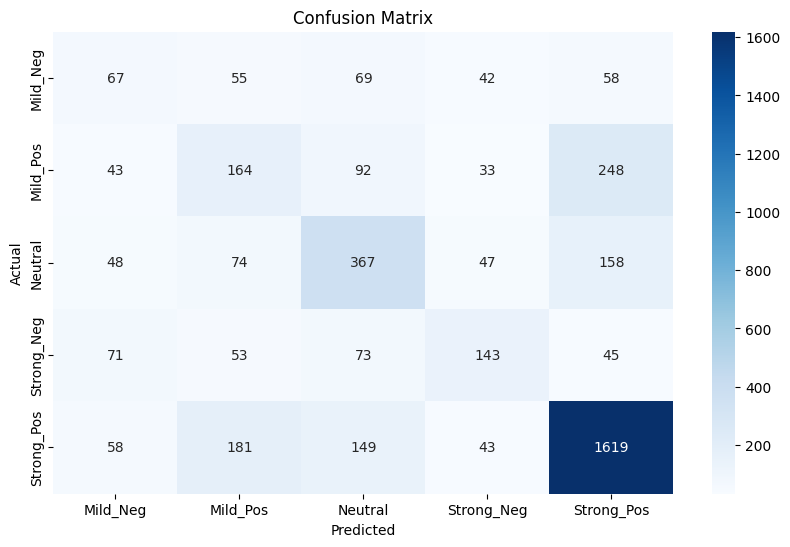

In [32]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Accuracy

\

Text(0.5, 1.0, 'Accuracy')

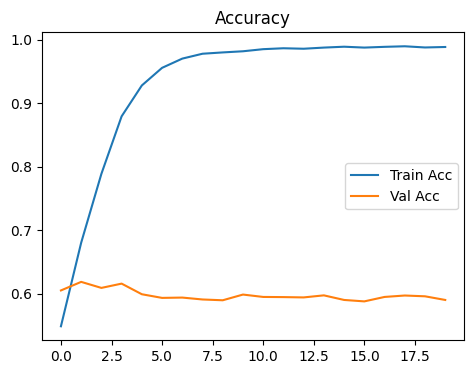

In [33]:
# Accuracy/Loss plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")


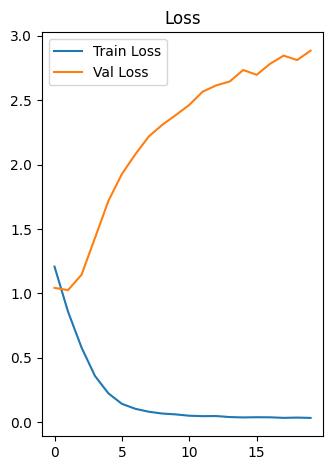

In [34]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.tight_layout()
plt.show()